<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
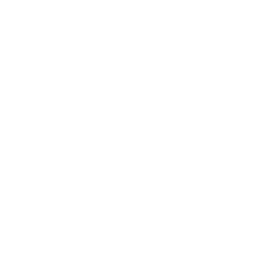
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analyse van stempatronen per stembureau</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Overheid / Verkiezingsstatistieken &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Deze analyse onderzoekt of politieke partijaffiliatie systematisch varieert
tussen stembureautypen (stedelijk, voorstedelijk, platteland) in een
gesimuleerde county-verkiezingsdataset van 100 stembureaus. Omdat verscheidene
partij-per-type cellen ijl bezet zijn — de kleinste kruistabelcellen bevatten
slechts één of twee stembureaus, met verwachte aantallen onder de vijf — is de
algemene Pearson chi-kwadraattoets voor samenhang hier onderbenut en
onbetrouwbaar. Daarom vullen we die aan met de **Cochran-Armitage-trendtoets**,
een gerichte toets met één vrijheidsgraad die de natuurlijke ordening van
stedelijk naar platteland benut en een scherpere vraag stelt: neemt de steun
voor Partij A monotoon af langs die gradiënt? De trendtoets rapporteert een
exacte p-waarde, wat de juiste inferentie is wanneer celaantallen klein zijn.
Het contrast tussen de twee toetsen is het analytische punt van dit voorbeeld:
een generieke samenhangtoets kan een echt richtingspatroon missen dat een
geordende trendtoets wel detecteert.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Records op stembureauniveau, één rij per stembureau, met stembureautype, county en de winnende partij | 100 |

De runtime draait in de licentievrije modus, die de uitvoer begrenst tot 100
waarnemingen; de analyse is ontworpen rond deze steekproef op stembureauniveau
zodat de kruistabelcellen daadwerkelijk klein zijn en de exacte trendtoets het
natuurlijke instrument is.

---

In [1]:
/* --------------------------------------------------------
   Genereer synthetische stemgegevens op stembureauniveau
   Kleine celaantallen in plattelandsstembureaus om de
   noodzaak van exacte toetsen te demonstreren
   -------------------------------------------------------- */
GEGEVENS work.precinct_votes;
    CALL streaminit(42);
    REEKS party_list[4] $15 _temporary_ ('PARTIJ_A' 'PARTIJ_B' 'PARTIJ_C' 'ONAFHANKELIJK');
    REEKS type_list[3] $15 _temporary_ ('STEDELIJK' 'VOORSTEDELIJK' 'PLATTELAND');
    REEKS county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    DOE precinct_seq = 1 TOT 500;
        precinct_id = cat('PCT-', SCHRIJVEN(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Ken stembureautype toe met weging */
        type_prob = rand('uniform');
        ALS type_prob < 0.30 DAN precinct_type = 'STEDELIJK';
        ANDERS ALS type_prob < 0.65 DAN precinct_type = 'VOORSTEDELIJK';
        ANDERS precinct_type = 'PLATTELAND';
        /* Ken partij toe met type-afhankelijke verdeling */
        party_prob = rand('uniform');
        ALS precinct_type = 'STEDELIJK' DAN DOE;
            ALS party_prob < 0.55 DAN party = 'PARTIJ_A';
            ANDERS ALS party_prob < 0.80 DAN party = 'PARTIJ_B';
            ANDERS ALS party_prob < 0.92 DAN party = 'PARTIJ_C';
            ANDERS party = 'ONAFHANKELIJK';
        EINDE;
        ANDERS ALS precinct_type = 'VOORSTEDELIJK' DAN DOE;
            ALS party_prob < 0.40 DAN party = 'PARTIJ_A';
            ANDERS ALS party_prob < 0.75 DAN party = 'PARTIJ_B';
            ANDERS ALS party_prob < 0.88 DAN party = 'PARTIJ_C';
            ANDERS party = 'ONAFHANKELIJK';
        EINDE;
        ANDERS DOE; /* PLATTELAND - kleinere cellen voor minderheidspartijen */
            ALS party_prob < 0.25 DAN party = 'PARTIJ_A';
            ANDERS ALS party_prob < 0.70 DAN party = 'PARTIJ_B';
            ANDERS ALS party_prob < 0.85 DAN party = 'PARTIJ_C';
            ANDERS party = 'ONAFHANKELIJK';
        EINDE;
        /* Aantal stemmen varieert per stembureautype */
        ALS precinct_type = 'STEDELIJK' DAN
            vote_count = int(rand('normal', 120, 40));
        ANDERS ALS precinct_type = 'VOORSTEDELIJK' DAN
            vote_count = int(rand('normal', 80, 25));
        ANDERS
            vote_count = int(rand('normal', 25, 12));
        ALS vote_count < 1 DAN vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        UITVOER;
    EINDE;
    VERWIJDEREN precinct_seq county_idx type_prob party_prob;
UITVOEREN;


NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---

                                                   The FREQ Procedure

Stembureautype    Frequency    Percent
---------------------------------------
PLATTELAND               34     34.00
STEDELIJK                29     29.00
VOORSTEDELIJK            37     37.00

Partij           Frequency    Percent
--------------------------------------
ONAFHANKELIJK            9      9.00
PARTIJ_A                45     45.00
PARTIJ_B                34     34.00
PARTIJ_C                12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


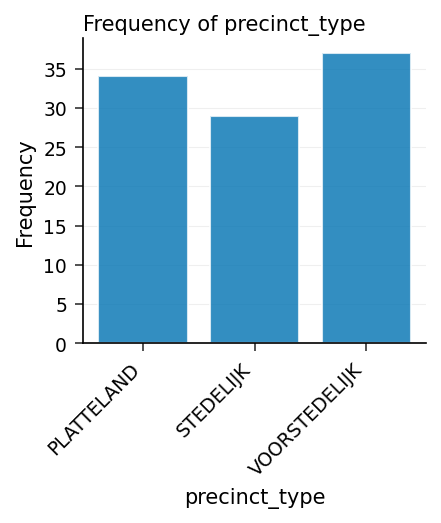

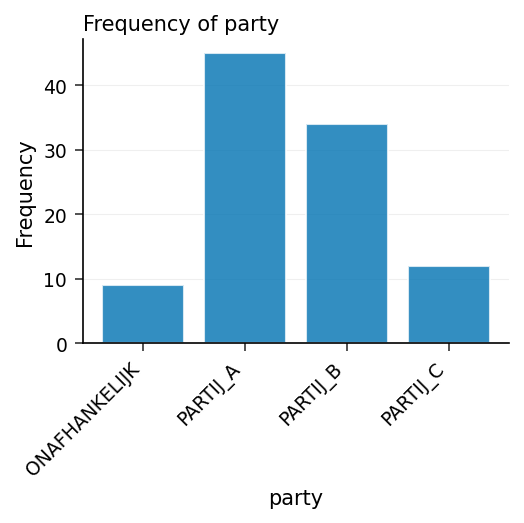

In [2]:
/* --------------------------------------------------------
   Basisverdeling van stembureautype en partij
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    label precinct_type='Stembureautype' party='Partij';
UITVOEREN;

---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


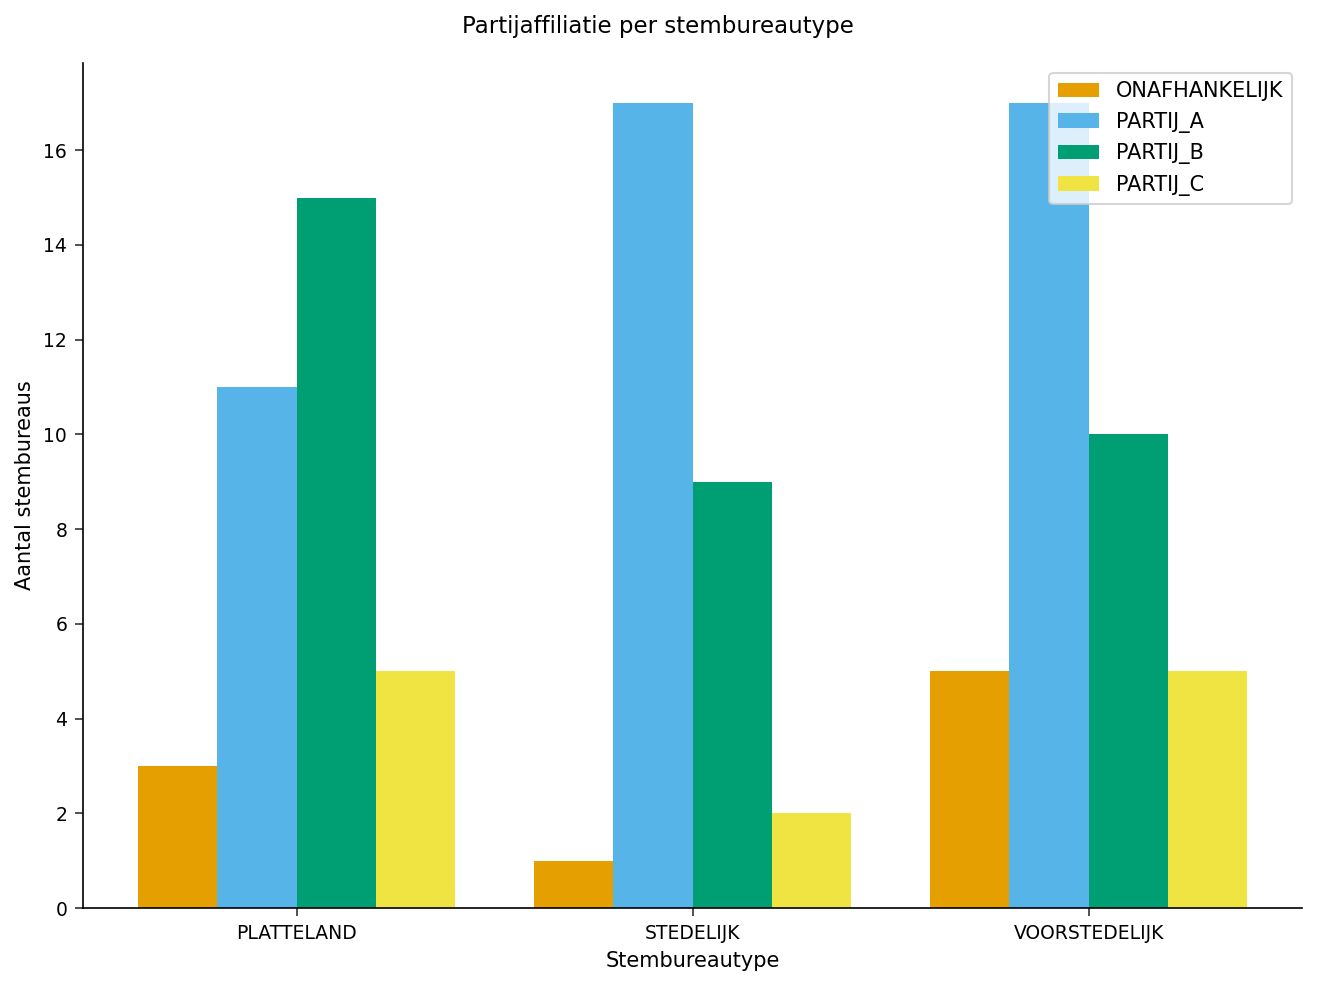

In [3]:
/* --------------------------------------------------------
   Partijaffiliatie per stembureautype (aantal stembureaus)
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=FREQUENTIES;
    label precinct_type='Stembureautype' party='Partij';
    XAXIS label='Stembureautype';
    YAXIS label='Aantal stembureaus';
    TITEL 'Partijaffiliatie per stembureautype';
UITVOEREN;

---

                             Stembureautype per partij: kruistabel met verwachte aantallen                              

                                                   The FREQ Procedure

Table of Stembureautype by Partij

Stembureautype |ONAFHANKELIJK |     PARTIJ_A |     PARTIJ_B |     PARTIJ_C |         Total
---------------+--------------+--------------+--------------+--------------+--------------
PLATTELAND     |            3 |           11 |           15 |            5 |            34
               |         3.00 |        11.00 |        15.00 |         5.00 |         34.00
               |         3.06 |        15.30 |        11.56 |         4.08 |              
               |         8.82 |        32.35 |        44.12 |        14.71 |        100.00
               |        33.33 |        24.44 |        44.12 |        41.67 |         34.00
---------------+--------------+--------------+--------------+--------------+--------------
STEDELIJK      |            1 |           17


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


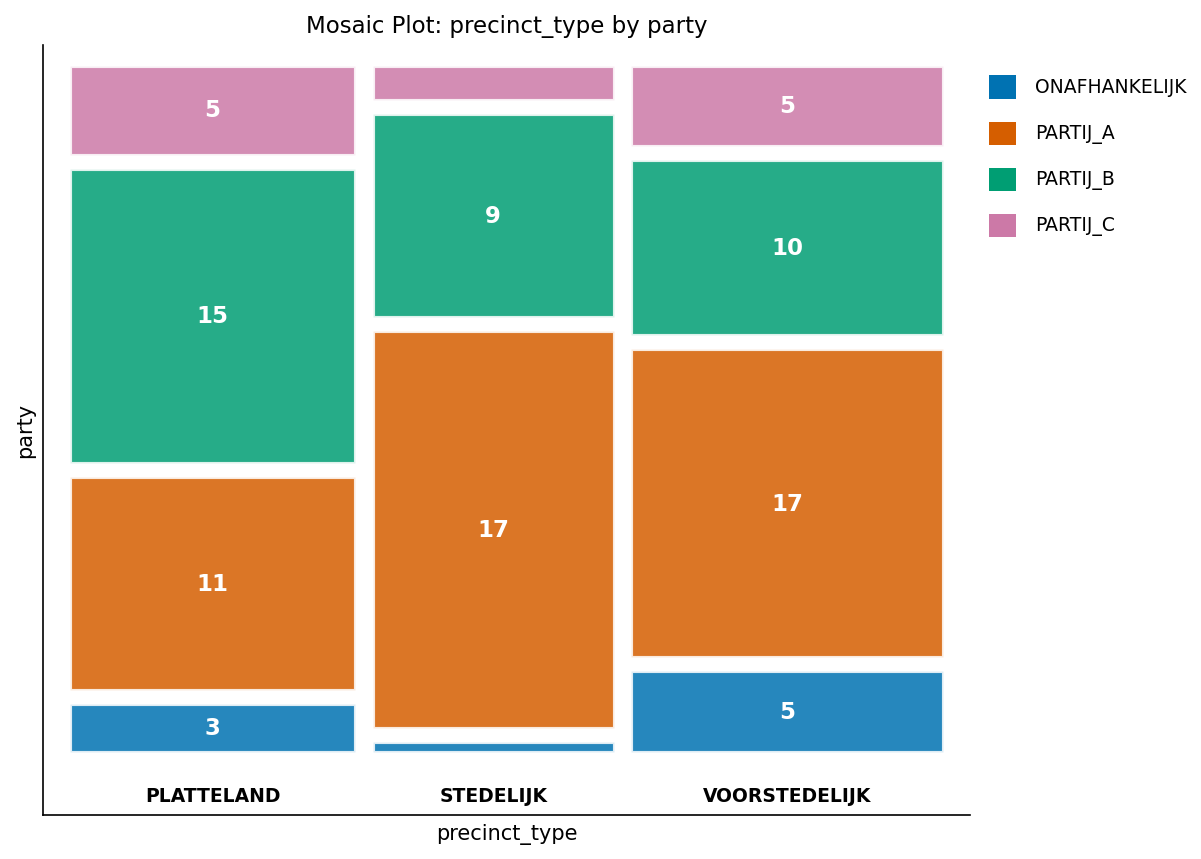

In [4]:
/* --------------------------------------------------------
   Kruistabel stembureautype x partij.
   Vraag VERWACHTE aantallen op zodat de ijle cellen zichtbaar
   zijn, plus de asymptotische Pearson chi-kwadraattoets voor
   algemene samenhang. Let op de kleine verwachte aantallen in
   de kolommen ONAFHANKELIJK en PARTIJ_C -- het signaal dat een
   geordende, exacte trendtoets het betere inferentie-instrument
   is.
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    label precinct_type='Stembureautype' party='Partij';
    TITEL 'Stembureautype per partij: kruistabel met verwachte aantallen';
UITVOEREN;

                      Cochran-Armitage-trendtoets: steun voor Partij A over de stembureaugradiënt                       

                                                   The FREQ Procedure

Table of Stembureautype (ordinaal) by Partij A (vlag)

Stembureautype (ordinaal) |         0 |         1 |      Total
--------------------------+-----------+-----------+-----------
1                         |        12 |        17 |         29
                          |     12.00 |     17.00 |      29.00
                          |     41.38 |     58.62 |     100.00
                          |     21.82 |     37.78 |      29.00
--------------------------+-----------+-----------+-----------
2                         |        20 |        17 |         37
                          |     20.00 |     17.00 |      37.00
                          |     54.05 |     45.95 |     100.00
                          |     36.36 |     37.78 |      37.00
--------------------------+-----------+-----------+--------


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


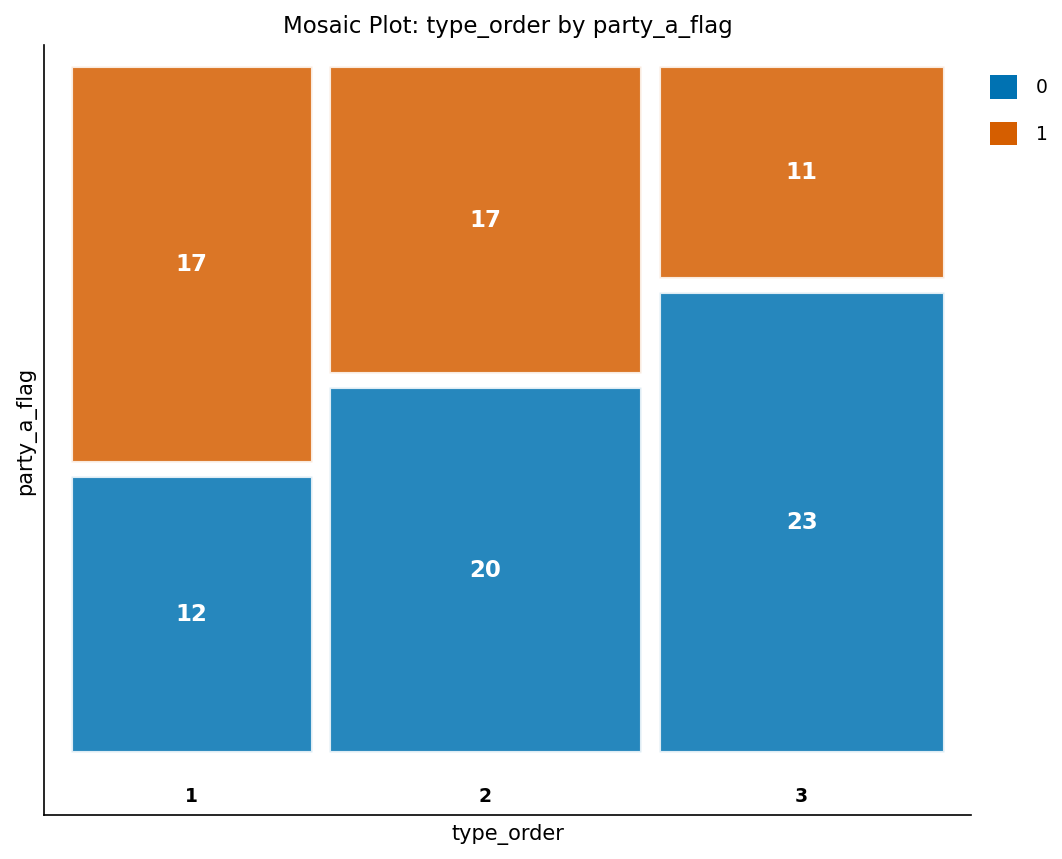

In [5]:
/* --------------------------------------------------------
   Cochran-Armitage-trendtoets. Hercodeer stembureautype naar
   een ordinale score (1=Stedelijk, 2=Voorstedelijk,
   3=Platteland) en toets of de steun voor Partij A een
   monotone trend vertoont langs de gradiënt. EXACT TREND
   vraagt de exacte p-waarde op, passend gezien de kleine
   celaantallen.
   -------------------------------------------------------- */
GEGEVENS work.precinct_ordinal;
    INSTELLEN work.precinct_votes;
    /* Ordinale codering: 1=Stedelijk, 2=Voorstedelijk, 3=Platteland */
    ALS precinct_type = 'STEDELIJK' DAN type_order = 1;
    ANDERS ALS precinct_type = 'VOORSTEDELIJK' DAN type_order = 2;
    ANDERS type_order = 3;
    /* Binaire uitkomst: Partij A versus alle andere affiliaties */
    party_a_flag = (party = 'PARTIJ_A');
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    label type_order='Stembureautype (ordinaal)' party_a_flag='Partij A (vlag)';
    TITEL 'Cochran-Armitage-trendtoets: steun voor Partij A over de stembureaugradiënt';
UITVOEREN;

                                       Verdeling van stembureautype binnen county                                       

                                                   The FREQ Procedure

Table of County by Stembureautype

County    |   PLATTELAND |    STEDELIJK |VOORSTEDELIJK |         Total
----------+--------------+--------------+--------------+--------------
ADAMS     |            5 |            4 |           10 |            19
          |         5.00 |         4.00 |        10.00 |         19.00
          |        26.32 |        21.05 |        52.63 |        100.00
          |        14.71 |        13.79 |        27.03 |         19.00
----------+--------------+--------------+--------------+--------------
HAMILTON  |            7 |            7 |            7 |            21
          |         7.00 |         7.00 |         7.00 |         21.00
          |        33.33 |        33.33 |        33.33 |        100.00
          |        20.59 |        24.14 |        18.92 |      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


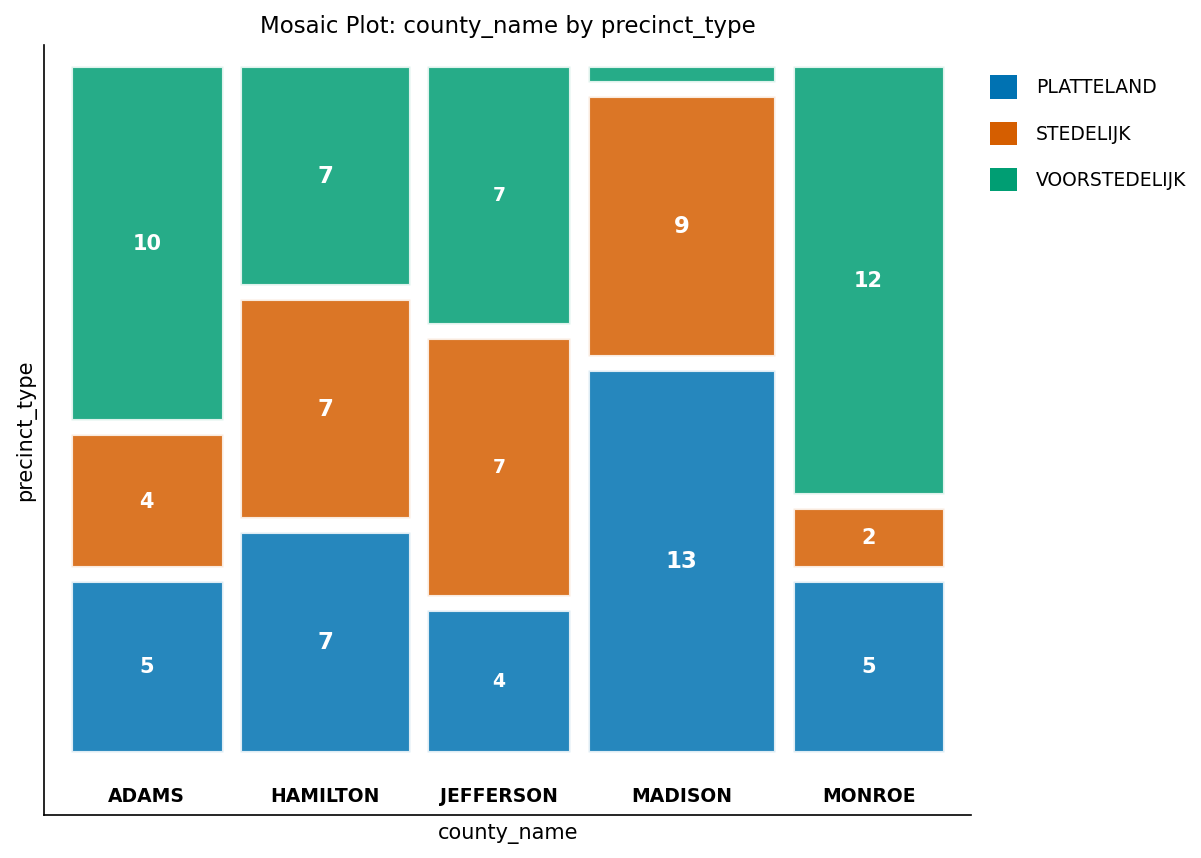

In [6]:
/* --------------------------------------------------------
   County-niveau: hoe de stedelijk/voorstedelijk/platteland-mix
   varieert tussen de vijf counties. Dit plaatst het
   trendresultaat in context -- de stembureaugradiënt is
   aanwezig in elke county, maar de samenstelling verschilt.
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    label county_name='County' precinct_type='Stembureautype';
    TITEL 'Verdeling van stembureautype binnen county';
UITVOEREN;

---

### Interpretatie

Over de 100 stembureaus heeft Partij A in totaal de meeste stemmen (45
stembureaus), gevolgd door Partij B (34), Partij C (12) en Onafhankelijken
(9). De kruistabel laat zien dat het aandeel van Partij A een duidelijke
gradiënt van stedelijk naar platteland volgt: het is goed voor 58,6% van de
stedelijke stembureaus, 46,0% van de voorstedelijke stembureaus en 32,4% van
de plattelandsstembureaus, terwijl Partij B de tegenovergestelde richting
opgaat en stijgt van 31,0% stedelijk naar 44,1% platteland.

De algemene Pearson chi-kwadraattoets voor samenhang is **niet** statistisch
significant (chi-kwadraat = 6,78, 6 vrijheidsgraden, p = 0,3418; Cramérs V =
0,18). Dat resultaat is bovendien kwetsbaar: de weergave van verwachte
aantallen laat verscheidene cellen onder de vijf zien — zo heeft de kolom
Onafhankelijk verwachte aantallen van 3,06, 3,33 en 2,61, en telt de
stedelijke Onafhankelijke groep slechts één stembureau — waardoor de
grote-steekproefbenadering van chi-kwadraat hier onbetrouwbaar is.

De Cochran-Armitage-trendtoets verscherpt de vraag door de ordinale
stedelijk-voorstedelijk-platteland-score te gebruiken. Hij detecteert de
monotone afname in steun voor Partij A die de algemene toets mist:
trend-chi-kwadraat = 4,38 met een asymptotische Pr > ChiSq = 0,0363 en een
**exacte Pr >= |Z| = 0,0431**, significant op het 0,05-niveau. Dit is de
analytische winst — een gerichte, exacte toets met één vrijheidsgraad
herkent een echt richtingssignaal dat de generieke toets met 6
vrijheidsgraden, verzwakt door ijle cellen, niet herkent.

Het overzicht op county-niveau bevestigt dat de verdeling
stedelijk/voorstedelijk/platteland in alle vijf counties aanwezig is, al
verschilt de samenstelling: Madison is het meest plattelandsgericht (13 van
de 23 stembureaus platteland), terwijl Monroe het meest voorstedelijk is (12
van de 19). Voor de beoordeling van de impact van herindeling is de
kernboodschap dat grensverschuivingen die stembureaus langs de
stedelijk-platteland-as verplaatsen de partijsamenstelling meetbaar zouden
veranderen, en dat deze geografische trend het best wordt aangetoond door de
exacte trendtoets in plaats van de algemene chi-kwadraattoets.

---

                                       Verdeling van stembureautype binnen county                                       

                                                   The FREQ Procedure

Table of Stembureautype by Partij

Stembureautype |ONAFHANKELIJK |     PARTIJ_A |     PARTIJ_B |     PARTIJ_C |         Total
---------------+--------------+--------------+--------------+--------------+--------------
PLATTELAND     |            3 |           11 |           15 |            5 |            34
               |         3.00 |        11.00 |        15.00 |         5.00 |         34.00
               |         8.82 |        32.35 |        44.12 |        14.71 |        100.00
               |        33.33 |        24.44 |        44.12 |        41.67 |         34.00
---------------+--------------+--------------+--------------+--------------+--------------
STEDELIJK      |            1 |           17 |            9 |            2 |            29
               |         1.00 |        17.00


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


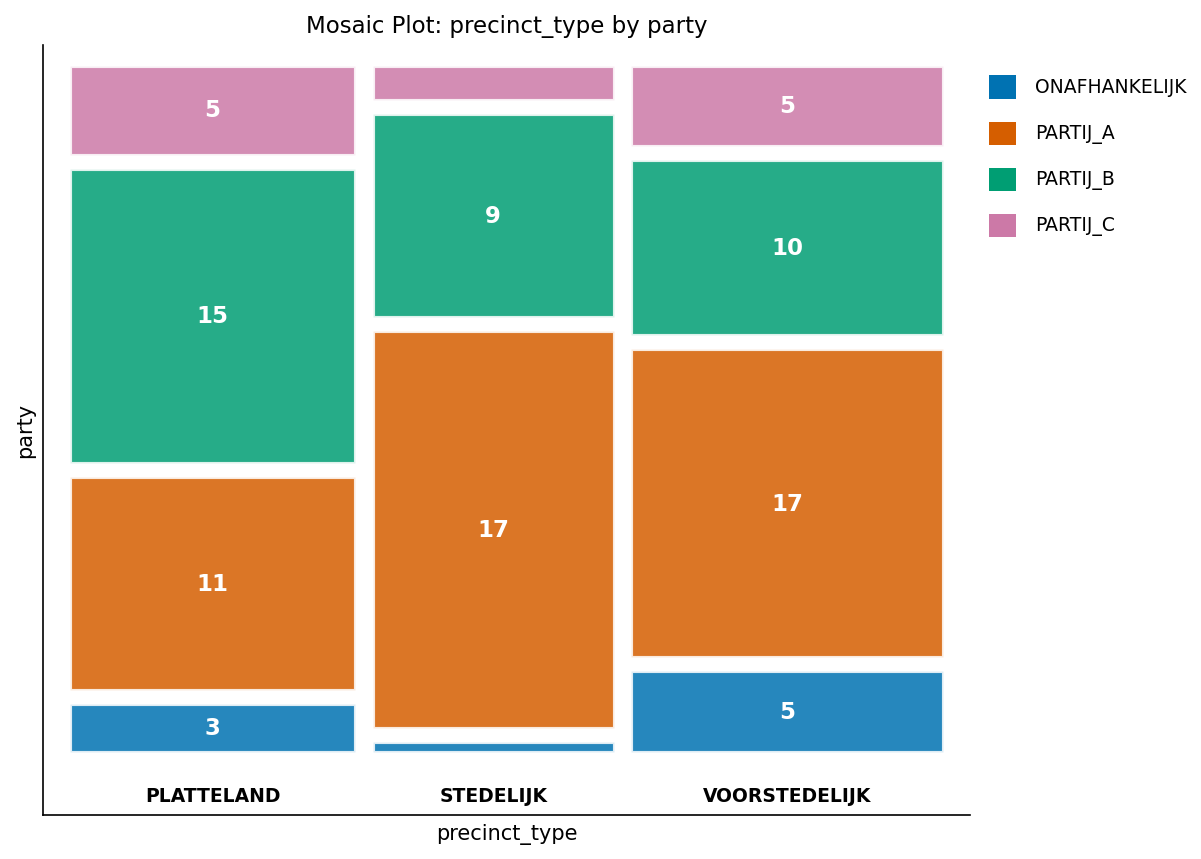

In [7]:
/* --------------------------------------------------------
   Exporteer de samenvatting stembureautype x partij voor
   verdere beoordeling van de impact van herindeling.
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
    label precinct_type='Stembureautype' party='Partij';
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
UITVOEREN;

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>